<a href="https://colab.research.google.com/github/singhshahrahul/AI-ML/blob/main/04Scikitlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#0. End to end Scikit-learn workflow

In [ ]:
#1. Get ready with data
heart_disease = pd.read_csv("/content/heart-disease.csv")

In [ ]:
#create C (feature matrix)
x = heart_disease.drop("target", axis=1)

#create Y (label)
y = heart_disease["target"]

In [ ]:
#2. choose the right model and hyperparameter
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators = 100)

In [ ]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [ ]:
#3. fit the model to the training data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
clf.fit(x_train, y_train);

In [ ]:
#4. predict the data
y_preds = clf.predict(x_test)
y_preds

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0])

In [ ]:
#5. evaluate the model on test and training data
clf.score(x_train, y_train)

1.0

In [ ]:
clf.score(x_test, y_test)

0.819672131147541

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.68      0.85      0.76        20
           1       0.92      0.80      0.86        41

    accuracy                           0.82        61
   macro avg       0.80      0.83      0.81        61
weighted avg       0.84      0.82      0.82        61



In [ ]:
confusion_matrix(y_test, y_preds)

array([[17,  3],
       [ 8, 33]])

In [ ]:
accuracy_score(y_test, y_preds)

0.819672131147541

In [ ]:
#6. improve the model by different n_estimators
np.random.seed(42)
for i in range(10, 100, 10):
  print(f"Trying model with {i} estimators...")
  clf = RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
  print(f"Model accuracy on test set: {clf.score(x_test, y_test)*100}%")
  print("")

Trying model with 10 estimators...
Model accuracy on test set: 80.32786885245902%

Trying model with 20 estimators...
Model accuracy on test set: 81.9672131147541%

Trying model with 30 estimators...
Model accuracy on test set: 77.04918032786885%

Trying model with 40 estimators...
Model accuracy on test set: 77.04918032786885%

Trying model with 50 estimators...
Model accuracy on test set: 80.32786885245902%

Trying model with 60 estimators...
Model accuracy on test set: 78.68852459016394%

Trying model with 70 estimators...
Model accuracy on test set: 80.32786885245902%

Trying model with 80 estimators...
Model accuracy on test set: 80.32786885245902%

Trying model with 90 estimators...
Model accuracy on test set: 81.9672131147541%



In [ ]:
#7. save a model and load it
import pickle
pickle.dump(clf, open("random_forest_model.pkl", "wb"))

In [ ]:
l_model = pickle.load(open("random_forest_model.pkl", "rb"))
l_model.score(x_test, y_test)

0.819672131147541

In [ ]:
len(heart_disease)

303

#1. Getting our data ready to be used with ML

In [ ]:
car_sales = pd.read_csv("/content/car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


1.1 make sure its all numerical

In [ ]:
#split x & y
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

#split into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
#Build ML model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
# model.fit(x_train, y_train)
# model.score(x_test, y_test)

In [ ]:
car_sales.dtypes

,0
Make,object
Colour,object
Odometer (KM),int64
Doors,int64
Price,int64


In [ ]:
#Turn the categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot,
                                  categorical_features)],
                                remainder="passthrough")

transformed_x = transformer.fit_transform(x)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [ ]:
pd.DataFrame(transformed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [ ]:
x

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4
3,Toyota,White,154365,4
4,Nissan,Blue,181577,3
...,...,...,...,...
995,Toyota,Black,35820,4
996,Nissan,White,155144,3
997,Nissan,Blue,66604,4
998,Honda,White,215883,4


In [ ]:
dummies = pd.get_dummies(car_sales[["Make", "Colour", "Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [ ]:
#refit the model
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(transformed_x, y,
                                                    test_size=0.2)

model.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
model.score(x_test, y_test)

0.3235867221569877

1.2 what if there were missing values?
1. fill them with some values(Imputation)
2. remove the samples with missing data altogether

In [ ]:
car_sales_missing = pd.read_csv("/content/car-sales-extended-missing-data.csv")
car_sales_missing.head(10)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
5,Honda,Red,42652.0,4.0,23883.0
6,Toyota,Blue,163453.0,4.0,8473.0
7,Honda,White,NaN,4.0,20306.0
8,NaN,White,130538.0,4.0,9374.0
9,Honda,Blue,51029.0,4.0,26683.0


In [ ]:
car_sales_missing.isna().sum()

,0
Make,49
Colour,50
Odometer (KM),50
Doors,50
Price,50


In [ ]:
len(car_sales_missing)

1000

In [ ]:
#Create X & Y
x = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

Option 1: Fill missing data with Pandas

In [ ]:
car_sales_missing["Make"].fillna("missing", inplace=True)
car_sales_missing["Colour"].fillna("missing", inplace=True)
car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean(), inplace=True)
car_sales_missing["Doors"].fillna(4, inplace=True)

/tmp/ipykernel_2237/2217192487.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_sales_missing["Make"].fillna("missing", inplace=True)
/tmp/ipykernel_2237/2217192487.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
car_sales_missing.isna().sum()

,0
Make,0
Colour,0
Odometer (KM),0
Doors,0
Price,50


remove rows with missing price value

In [ ]:
car_sales_missing.dropna(inplace=True)

In [ ]:
car_sales_missing.isna().sum()

,0
Make,0
Colour,0
Odometer (KM),0
Doors,0
Price,0


In [ ]:
len(car_sales_missing)

950

In [ ]:
#change into numbers
categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot,
                                  categorical_features)],
                                remainder="passthrough")
transformed_x = transformer.fit_transform(car_sales_missing)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]])

option 2: fill missing values with scikitlearn.

In [ ]:
car_sales_missing = pd.read_csv("/content/car-sales-extended-missing-data.csv")
car_sales_missing.isna().sum()

,0
Make,49
Colour,50
Odometer (KM),50
Doors,50
Price,50


In [ ]:
#remove the rows with no lables
car_sales_missing.dropna(subset=["Price"], inplace=True)
car_sales_missing.isna().sum()

,0
Make,47
Colour,46
Odometer (KM),48
Doors,47
Price,0


In [ ]:
x = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

In [ ]:
#fill with scikit learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

#fill categorical value with "missing" & numerical with mean
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

#define columns
cat_features = ["Make", "Colour"]
door_features = ["Doors"]
num_features = ["Odometer (KM)"]

#create a imputer (something that fills missing data)
imputer = ColumnTransformer([("cat_imputer", cat_imputer, cat_features),
                             ("door_imputer", door_imputer, door_features),
                             ("num_imputer", num_imputer, num_features)])

#transform the data
filled_x = imputer.fit_transform(x)
filled_x

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], dtype=object)

In [ ]:
car_sales_filled = pd.DataFrame(filled_x, columns=["Make", "Colour", "Doors", "Odometer (KM)"])
car_sales_filled.head(10)

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0
5,Honda,Red,4.0,42652.0
6,Toyota,Blue,4.0,163453.0
7,Honda,White,4.0,130987.447894
8,missing,White,4.0,130538.0
9,Honda,Blue,4.0,51029.0


In [ ]:
car_sales_filled.isna().sum()

,0
Make,0
Colour,0
Doors,0
Odometer (KM),0


In [ ]:
#change into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot, categorical_features)],
                                remainder = "passthrough")

transformed_x = transformer.fit_transform(car_sales_filled)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [ ]:
# fit in a model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(transformed_x, y, test_size = 0.2)

model =  RandomForestRegressor()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.19174198677009124

#2. Choosing the right estimator/algorithm for our model

scikit learn uses estimator as another term for ML model or algo.
1. classification
2. regression

Picking a ML model for regression Problem

In [ ]:
#Import house data
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing;

In [ ]:
housing_df = pd.DataFrame(housing["data"], columns=housing["feature_names"])
housing_df["target"] = pd.Series(housing["target"])
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
len(housing_df)

20640

In [ ]:
from sklearn.linear_model import Ridge

x = housing_df.drop("target", axis=1)
y = housing_df["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = Ridge()
model.fit(x_train, y_train)

Ridge()

In [ ]:
model.score(x_test, y_test)

0.6147292170282506

how do we improve the score?

what if Ridge wasn't working?

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
rf.score(x_test, y_test)

0.8145135012417195

choosing an estimator for classification problem

In [ ]:
heart_disease = pd.read_csv("/content/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
len(heart_disease)

303

In [ ]:
#Import the linearSVC estimator
from sklearn.svm import LinearSVC

x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

svc = LinearSVC().fit(x_train, y_train)
svc.score(x_test, y_test)

0.8688524590163934

In [ ]:
#Import the RandomForestClassifier estimator
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
rfc.score(x_test, y_test)

0.819672131147541

#3. Fit the Model/algorithm on our data and use it to make predictions

3.1: fitting the model to the data
* x - Feature, data
* y - Target, Labels

In [ ]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

rfc = RandomForestClassifier(n_estimators=40)
rfc.fit(x_train, y_train)
rfc.score(x_test, y_test)

0.8688524590163934

3.2 Make prediction using ML model
1. predict()
2. predict_proba()

In [ ]:
x_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [ ]:
rfc.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
#compare prediction to truth label to evaluate the model
y_preds = rfc.predict(x_test)
np.mean(y_preds == y_test)

np.float64(0.8688524590163934)

In [ ]:
rfc.score(x_test, y_test)

0.8688524590163934

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)

0.8688524590163934

Make prediction with predict_proba()

In [ ]:
#predict_proba() returns the Prob. of classification model
rfc.predict_proba(x_test[:5])

array([[0.9  , 0.1  ],
       [0.45 , 0.55 ],
       [0.4  , 0.6  ],
       [0.8  , 0.2  ],
       [0.175, 0.825]])

In [ ]:
rfc.predict(x_test[:5])

array([0, 1, 1, 0, 1])

In [ ]:
x_test[:5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [ ]:
heart_disease["target"].value_counts()

,count
target,
1,165
0,138


predict() can also be used for regression problems

In [ ]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
from sklearn.ensemble import RandomForestRegressor

x = housing_df.drop("target", axis=1)
y = housing_df["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
y_preds = model.predict(x_test)
y_preds[:10]

array([3.9980913, 1.45839  , 2.95766  , 0.83256  , 2.29594  , 1.60102  ,
       1.59469  , 3.6567606, 2.6475804, 2.13533  ])

In [ ]:
np.array(y_test[:5])

array([3.307, 0.746, 3.267, 0.62 , 1.618])

In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.33499220472383734

#4. Evaluating a ML model

three ways to evaluate ML model
1. Estimator `score` method
2. The `scoring` parameter
3. Problem-specific matric function.

In [ ]:
#score method for classification
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

rfc = RandomForestClassifier(n_estimators=40)
rfc.fit(x_train, y_train)
rfc.score(x_test, y_test)

0.8688524590163934

In [ ]:
#for regression
from sklearn.ensemble import RandomForestRegressor

x = housing_df.drop("target", axis=1)
y = housing_df["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
#scoring parameter
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

rfc = RandomForestClassifier(n_estimators=40)
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=40)

In [ ]:
cross_score = cross_val_score(rfc, x, y, cv=5)

In [ ]:
np.mean(cross_score)

np.float64(0.8084153005464481)

AUC or ROC curve

ROC is a comparison of "tpr" vs "fpr"

In [ ]:
from sklearn.metrics import roc_curve

rfc.fit(x_train, y_train)

y_prob = rfc.predict_proba(x_test)

y_prob[:10]

array([[0.8  , 0.2  ],
       [0.5  , 0.5  ],
       [0.45 , 0.55 ],
       [0.875, 0.125],
       [0.2  , 0.8  ],
       [0.15 , 0.85 ],
       [0.225, 0.775],
       [0.925, 0.075],
       [0.925, 0.075],
       [0.5  , 0.5  ]])

In [ ]:
ypp = y_prob[:, 1]
ypp[:10]

array([0.2  , 0.5  , 0.55 , 0.125, 0.8  , 0.85 , 0.775, 0.075, 0.075,
       0.5  ])

In [ ]:
fpr, tpr, thresholds  = roc_curve(y_test, ypp)
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.06896552, 0.06896552, 0.06896552, 0.06896552,
       0.13793103, 0.13793103, 0.13793103, 0.17241379, 0.17241379,
       0.20689655, 0.20689655, 0.27586207, 0.31034483, 0.44827586,
       0.55172414, 0.5862069 , 0.65517241, 0.93103448, 1.        ])

In [ ]:
#function for plotting ROC curve
def plot_roc_curve(fpr, tpr):
  plt.plot(fpr, tpr, color="green", label="ROC")
  plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend()
  plt.show()

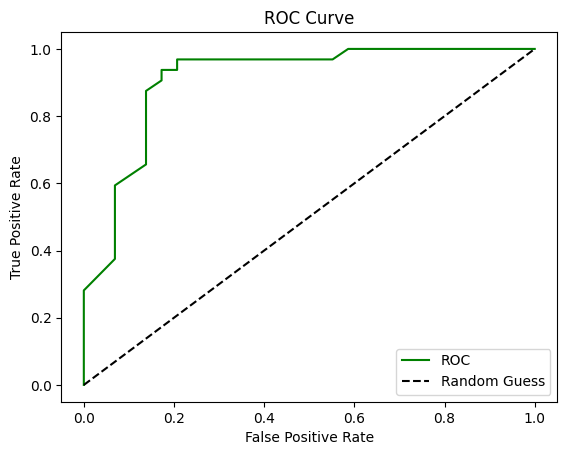

In [ ]:
plot_roc_curve(fpr, tpr)

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, ypp)

np.float64(0.9105603448275863)

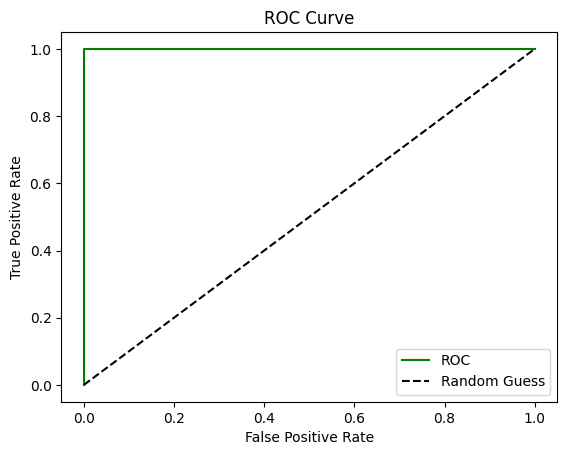

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test)
plot_roc_curve(fpr, tpr)

In [ ]:
roc_auc_score(y_test, y_test)

np.float64(1.0)